In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# EDA – Chargeback Fraud Challenge
Chaque ligne correspond à un compte client au moment où la plateforme doit décider d’autoriser, bloquer ou revoir une activité. L’objectif est de prédire la variable binaire target_is_fraud (1 = chargeback / fraude, 0 = comportement normal) pour construire un modèle de détection de fraude exploitable.

In [2]:
df = pd.read_csv('../data/kaggle_b2_fraud_train_v3.csv')
df

,customer_id,account_id,age,tenure_months,annual_income_eur,credit_score,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,days_since_last_login,...,internal_signal_5,internal_signal_6,internal_signal_7,internal_signal_8,terms_accepted_flag,partner_risk_indicator,manual_review_result,post_event_status_code,chargeback_resolution_time_days,legacy_partner_score
0,CUST_6O9Q8D4I36,ACC_TXXXTNEUVKFY,34,108,38635.01,544.0,20,60.92,80.16,4.9,...,0.39006,0.10963,0.55097,-0.56104,1,NaN,approve,0,7.9,NaN
1,CUST_FGUGTW230C,ACC_70VD7A4FFWCW,48,2,19912.97,703.0,21,112.11,571.12,0.3,...,0.03265,-0.40256,0.36218,0.86583,1,NaN,approve,0,5.5,NaN
2,CUST_8ZI3LCBZ0W,ACC_AF53381QSC0L,27,0,20326.87,720.0,25,73.61,492.57,4.6,...,-0.15637,0.57818,0.28902,-2.19864,1,NaN,approve,0,7.2,NaN
3,CUST_5MP3AR41CJ,ACC_U7WZGJ486LIV,45,49,38452.47,703.0,17,47.53,204.18,25.3,...,-1.02145,0.63908,-0.89190,-0.81592,1,NaN,approve,0,4.4,NaN
4,CUST_GNPL83JB0J,ACC_XW7DS3ED5J4Y,37,46,NaN,594.0,13,99.95,734.09,12.8,...,-0.65771,0.08020,0.17606,0.86739,1,NaN,approve,0,4.9,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159995,CUST_I81IW5SVRQ,ACC_UPDTFTYTSM0A,56,0,34775.62,727.0,21,51.72,226.11,3.8,...,-2.54086,-0.60747,0.23252,-0.06215,1,-1.535486,approve,0,1.0,NaN
159996,CUST_QT6DDEMKTJ,ACC_97NE0LBL5W9U,41,4,88617.57,770.0,18,NaN,171.07,15.1,...,0.34098,-1.78817,0.31788,0.51072,1,NaN,approve,0,7.4,NaN
159997,CUST_I0JS1GTS98,ACC_9JJ84W64Z7GX,30,2,41148.54,738.0,20,29.34,119.81,0.7,...,-1.28947,-0.32324,-0.06238,-0.99076,1,NaN,approve,3,6.6,NaN
159998,CUST_L7GUCJ3TFY,ACC_NGFXDR7HW1ZS,56,6,NaN,719.0,25,88.56,553.16,22.6,...,0.47179,-0.22090,-1.34239,-0.30513,1,NaN,approve,0,12.5,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160000 entries, 0 to 159999
Data columns (total 56 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   customer_id                      160000 non-null  object 
 1   account_id                       160000 non-null  object 
 2   age                              160000 non-null  int64  
 3   tenure_months                    160000 non-null  int64  
 4   annual_income_eur                148814 non-null  float64
 5   credit_score                     152048 non-null  float64
 6   num_transactions_30d             160000 non-null  int64  
 7   avg_amount_30d_eur               150453 non-null  float64
 8   max_amount_30d_eur               152077 non-null  float64
 9   days_since_last_login            160000 non-null  float64
 10  support_tickets_90d              160000 non-null  int64  
 11  chargebacks_12m                  160000 non-null  int64  
 12  fa

In [4]:
df.isna().sum().sort_values(ascending=False)

partner_risk_indicator             155249
legacy_partner_score               153736
secondary_email                    147391
region                              45240
annual_income_eur                   11186
avg_amount_30d_eur                   9547
credit_score                         7952
max_amount_30d_eur                   7923
device_trust_z                       6384
customer_note                        4802
occupation                           4772
ip_risk_z                            4767
last_ticket_subject                  4720
merchant_category                    3138
max_to_avg_ratio                        0
tx_amount_total_30d_eur                 0
income_estimate_alt_eur                 0
credit_score_norm                       0
internal_signal_2                       0
income_log                              0
internal_signal_1                       0
internal_signal_4                       0
internal_signal_3                       0
tenure_months                     

In [5]:
((df.isna().sum() / len(df)) * 100).sort_values(ascending=False)

partner_risk_indicator             97.030625
legacy_partner_score               96.085000
secondary_email                    92.119375
region                             28.275000
annual_income_eur                   6.991250
avg_amount_30d_eur                  5.966875
credit_score                        4.970000
max_amount_30d_eur                  4.951875
device_trust_z                      3.990000
customer_note                       3.001250
occupation                          2.982500
ip_risk_z                           2.979375
last_ticket_subject                 2.950000
merchant_category                   1.961250
max_to_avg_ratio                    0.000000
tx_amount_total_30d_eur             0.000000
income_estimate_alt_eur             0.000000
credit_score_norm                   0.000000
internal_signal_2                   0.000000
income_log                          0.000000
internal_signal_1                   0.000000
internal_signal_4                   0.000000
internal_s

-> Supprimer les 3 colonnes avec > 90% de NaN.

In [6]:
df['region'].value_counts()

region
Île-de-France                 31692
Auvergne-Rhône-Alpes          14731
Nouvelle-Aquitaine             9217
Provence-Alpes-Côte d'Azur     8894
Grand Est                      8093
Occitanie                      7881
Hauts-de-France                7774
Pays de la Loire               6907
Bretagne                       5757
Normandie                      4583
Centre-Val de Loire            4556
Bourgogne-Franche-Comté        3454
Ile-de-France                   609
Auvergne Rhone Alpes            291
Provence Alpes Cote d Azur      161
Hauts de France                 160
Name: count, dtype: int64

-> Assembler les colonnes avec le même nom mais qui ont une écriture différente.

In [7]:
df.duplicated().sum()

8

## Demographics & Account Information

In [8]:
df[df['customer_id'].duplicated()]

,customer_id,account_id,age,tenure_months,annual_income_eur,credit_score,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,days_since_last_login,...,internal_signal_5,internal_signal_6,internal_signal_7,internal_signal_8,terms_accepted_flag,partner_risk_indicator,manual_review_result,post_event_status_code,chargeback_resolution_time_days,legacy_partner_score
3920,CUST_1JWF0MV6ME,ACC_TWAT90YD8WTO,46,8,51005.61,498.0,17,5.10,31.10,0.8,...,1.12049,0.11956,0.28136,-0.53657,1,NaN,review,0,4.3,NaN
6152,CUST_A6W0XYAX3R,ACC_MZ149Z8EXKQN,28,11,42470.73,761.0,21,98.51,258.69,0.1,...,1.10332,-0.44832,1.42614,-1.76276,1,NaN,review,0,5.0,NaN
6224,CUST_V61CFIW4OF,ACC_CSPKB9VILFGT,57,11,29734.15,528.0,16,16.80,26.53,6.5,...,-0.40692,1.41257,0.36476,-0.12286,1,NaN,approve,0,0.0,NaN
6402,CUST_CYFOQPFB86,ACC_UFDQT5BEPM4L,45,4,60477.30,719.0,20,130.44,527.96,20.2,...,-1.19207,-0.84240,-1.75474,1.13479,1,NaN,approve,0,1.9,NaN
7266,CUST_46ZHI93WRK,ACC_3D108BN1JRHJ,23,4,30988.59,724.0,19,63.22,352.55,7.0,...,1.42903,-0.15345,0.79068,-0.18386,1,NaN,approve,0,12.1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159790,CUST_TEPHB6IALE,ACC_X87Z2AXWE3JC,40,3,77269.81,678.0,15,132.15,664.05,0.9,...,1.44789,-0.58461,0.79760,1.99010,1,NaN,approve,0,6.0,NaN
159799,CUST_1DBX8X386G,ACC_18OMX9OH3435,32,22,41665.34,805.0,25,169.57,992.12,2.8,...,-1.40872,0.47979,-0.17563,-0.97137,1,NaN,review,0,5.3,NaN
159841,CUST_STRFGKP3RI,ACC_AU4T3L4JK0JZ,38,2,20458.03,636.0,27,37.50,250.12,14.5,...,1.38186,-0.42891,-0.89361,0.38159,1,0.379901,approve,0,3.7,-0.748895
159968,CUST_799JRJNSEN,ACC_4DAC8CZJWO32,55,6,NaN,712.0,24,41.98,274.08,29.0,...,1.62357,-0.69823,0.23450,-0.23396,1,NaN,approve,0,2.0,NaN


In [9]:
df[df['account_id'].duplicated()]

,customer_id,account_id,age,tenure_months,annual_income_eur,credit_score,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,days_since_last_login,...,internal_signal_5,internal_signal_6,internal_signal_7,internal_signal_8,terms_accepted_flag,partner_risk_indicator,manual_review_result,post_event_status_code,chargeback_resolution_time_days,legacy_partner_score
3920,CUST_1JWF0MV6ME,ACC_TWAT90YD8WTO,46,8,51005.61,498.0,17,5.10,31.10,0.8,...,1.12049,0.11956,0.28136,-0.53657,1,NaN,review,0,4.3,NaN
6152,CUST_A6W0XYAX3R,ACC_MZ149Z8EXKQN,28,11,42470.73,761.0,21,98.51,258.69,0.1,...,1.10332,-0.44832,1.42614,-1.76276,1,NaN,review,0,5.0,NaN
6224,CUST_V61CFIW4OF,ACC_CSPKB9VILFGT,57,11,29734.15,528.0,16,16.80,26.53,6.5,...,-0.40692,1.41257,0.36476,-0.12286,1,NaN,approve,0,0.0,NaN
6402,CUST_CYFOQPFB86,ACC_UFDQT5BEPM4L,45,4,60477.30,719.0,20,130.44,527.96,20.2,...,-1.19207,-0.84240,-1.75474,1.13479,1,NaN,approve,0,1.9,NaN
7266,CUST_46ZHI93WRK,ACC_3D108BN1JRHJ,23,4,30988.59,724.0,19,63.22,352.55,7.0,...,1.42903,-0.15345,0.79068,-0.18386,1,NaN,approve,0,12.1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159790,CUST_TEPHB6IALE,ACC_X87Z2AXWE3JC,40,3,77269.81,678.0,15,132.15,664.05,0.9,...,1.44789,-0.58461,0.79760,1.99010,1,NaN,approve,0,6.0,NaN
159799,CUST_1DBX8X386G,ACC_18OMX9OH3435,32,22,41665.34,805.0,25,169.57,992.12,2.8,...,-1.40872,0.47979,-0.17563,-0.97137,1,NaN,review,0,5.3,NaN
159841,CUST_STRFGKP3RI,ACC_AU4T3L4JK0JZ,38,2,20458.03,636.0,27,37.50,250.12,14.5,...,1.38186,-0.42891,-0.89361,0.38159,1,0.379901,approve,0,3.7,-0.748895
159968,CUST_799JRJNSEN,ACC_4DAC8CZJWO32,55,6,NaN,712.0,24,41.98,274.08,29.0,...,1.62357,-0.69823,0.23450,-0.23396,1,NaN,approve,0,2.0,NaN


-> Un utilisateur = un compte, supprimer l'une des deux colonnes ?

-> Supprimer les duplicates.

In [11]:
df['age'].sort_values(ascending=False)

26847     159
45658     159
132490    155
102886    155
32677     155
         ... 
22879     -14
123267    -14
111221    -14
27803     -14
54410     -14
Name: age, Length: 160000, dtype: int64

-> Supprimer les outliers.

In [12]:
df['tenure_months'][df['tenure_months'] <= 1].value_counts()

tenure_months
 1     8315
 0     4315
-8       13
-6       12
-7       12
-20      12
-9       12
-15      10
-17      10
-11      10
-12      10
-14       9
-19       9
-13       9
-3        8
-4        8
-22       8
-5        7
-2        7
-16       7
-1        7
-18       6
-10       6
-23       6
-21       5
Name: count, dtype: int64

-> Supprimer les données négatives.

## Transactional & Behavioral Features

In [13]:
# Revenue annuel négatif
df['annual_income_eur'][df['annual_income_eur'] <= 0].value_counts().sum()

117

-> A supprimer.

In [14]:
df['credit_score'].min()

380.0

In [15]:
df['credit_score'].max()

850.0

- 300-579 : Very poor
- 580-600 : Poor
- 601-660 : Fair
- 670-739 : Good
- 740-799 : Very good
- 800-850 : Exceptional

-> Donc min et max cohérents.

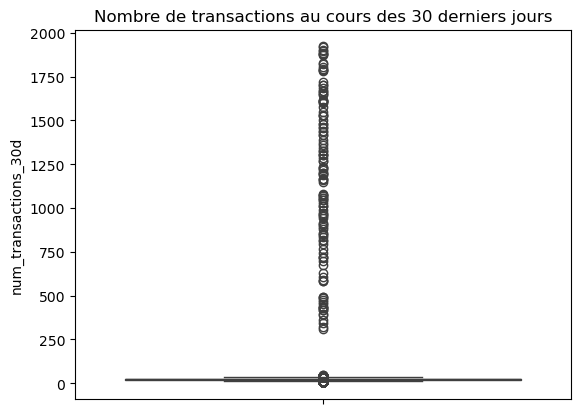

In [16]:
sns.boxplot(y=df['num_transactions_30d'])
plt.title('Nombre de transactions au cours des 30 derniers jours')
plt.show()

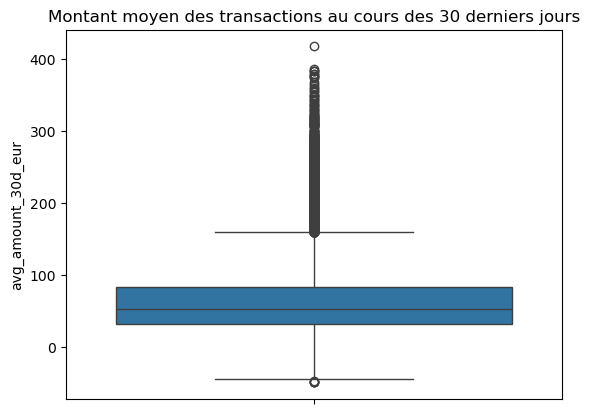

In [17]:
sns.boxplot(y=df['avg_amount_30d_eur'])
plt.title('Montant moyen des transactions au cours des 30 derniers jours')
plt.show()

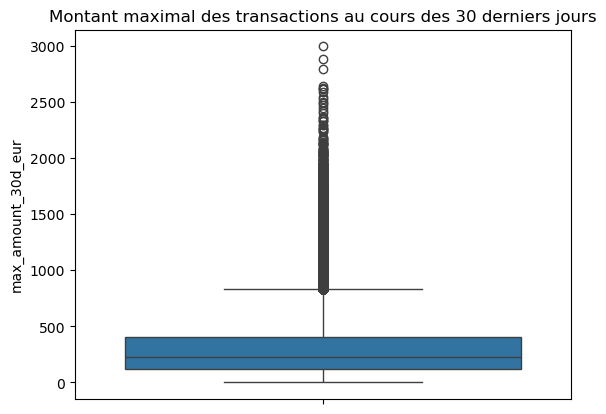

In [18]:
sns.boxplot(y=df['max_amount_30d_eur'])
plt.title('Montant maximal des transactions au cours des 30 derniers jours')
plt.show()

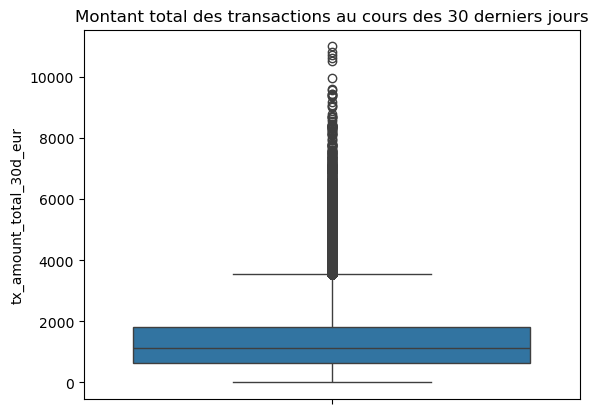

In [19]:
sns.boxplot(y=df['tx_amount_total_30d_eur'])
plt.title('Montant total des transactions au cours des 30 derniers jours')
plt.show()

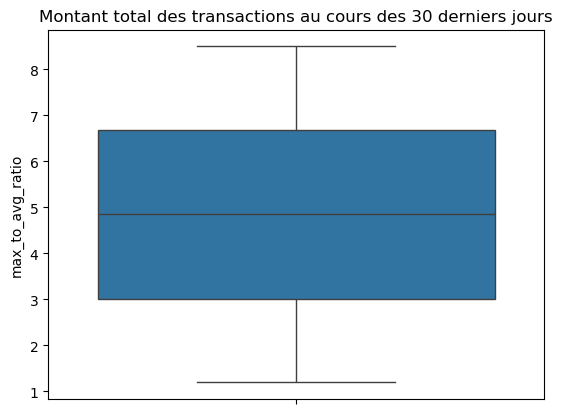

In [20]:
sns.boxplot(y=df['max_to_avg_ratio'])
plt.title('Montant total des transactions au cours des 30 derniers jours')
plt.show()

In [21]:
df['max_to_avg_ratio'].sort_values()

14749     1.1989
67395     1.2001
105021    1.2001
129043    1.2001
131260    1.2003
           ...  
73792     8.4999
4043      8.5000
120021    8.5000
51489     8.5000
141151    8.5000
Name: max_to_avg_ratio, Length: 160000, dtype: float64

-> 1 : comportement de paiement régulier, pas de transaction très différente des autres.

-> 8 : certains clients ont eu une transaction jusqu’à 8 fois plus élevée que leur moyenne, ce qui peut être un signal de comportement anormal (ex. gros achat ponctuel) à tester par rapport à target_is_fraud.

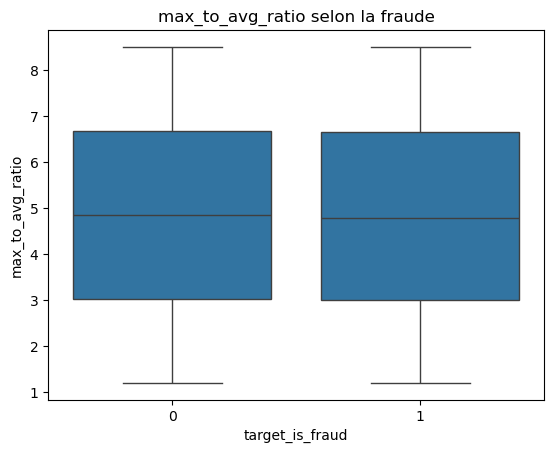

In [22]:
sns.boxplot(x=df['target_is_fraud'], y=df['max_to_avg_ratio'])
plt.title('max_to_avg_ratio selon la fraude')
plt.show()

-> Le max_to_avg_ratio n'est pas un facteur déterminant puisque la distribution est similaire.

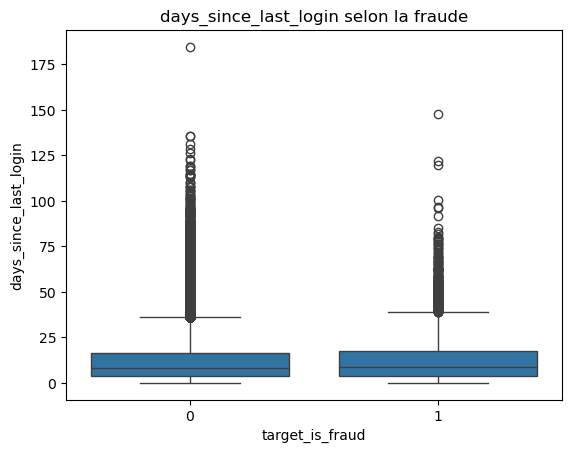

In [33]:
sns.boxplot(x=df['target_is_fraud'], y=df['days_since_last_login'])
plt.title('days_since_last_login selon la fraude')
plt.show()

In [31]:
df.groupby('target_is_fraud')['support_tickets_90d'].value_counts(normalize=True)

target_is_fraud  support_tickets_90d
0                0                      0.450921
                 1                      0.360056
                 2                      0.141821
                 3                      0.037936
                 4                      0.007790
                 5                      0.001270
                 6                      0.000193
                 7                      0.000013
1                0                      0.429732
                 1                      0.359870
                 2                      0.158002
                 3                      0.040820
                 4                      0.009139
                 5                      0.001828
                 6                      0.000609
Name: proportion, dtype: float64

In [35]:
df.groupby('target_is_fraud')['chargebacks_12m'].value_counts(normalize=True)

target_is_fraud  chargebacks_12m
0                0                  0.951933
                 1                  0.046958
                 2                  0.001083
                 3                  0.000026
1                0                  0.929326
                 1                  0.068440
                 2                  0.002234
Name: proportion, dtype: float64

In [39]:
df.groupby('target_is_fraud')['failed_payments_6m'].value_counts(normalize=True)

target_is_fraud  failed_payments_6m
0                0                     0.705989
                 1                     0.246086
                 2                     0.042850
                 3                     0.004649
                 4                     0.000400
                 5                     0.000026
1                0                     0.659220
                 1                     0.274370
                 2                     0.056864
                 3                     0.008327
                 4                     0.000812
                 5                     0.000203
                 6                     0.000203
Name: proportion, dtype: float64

1 > 0

## Device & Risk Signals

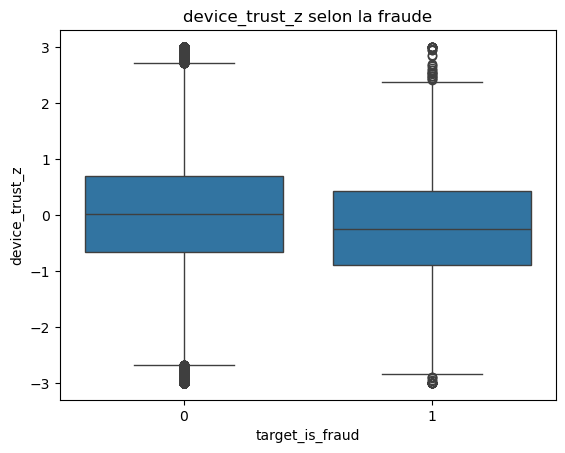

In [46]:
sns.boxplot(x=df['target_is_fraud'], y=df['device_trust_z'])
plt.title('device_trust_z selon la fraude')
plt.show()

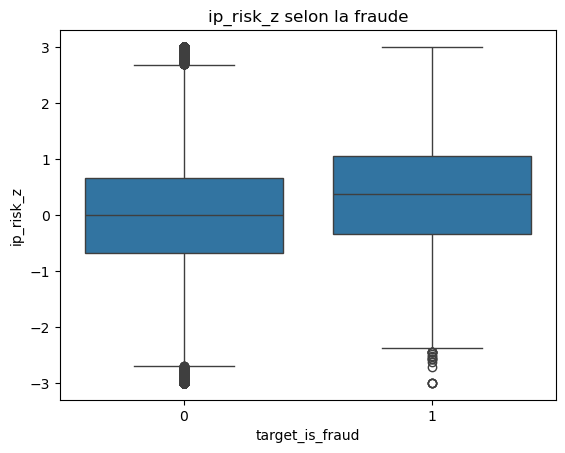

In [48]:
sns.boxplot(x=df['target_is_fraud'], y=df['ip_risk_z'])
plt.title('ip_risk_z selon la fraude')
plt.show()

In [53]:
df.groupby('target_is_fraud')['is_vpn'].value_counts(normalize=True)

target_is_fraud  is_vpn
0                0         0.921123
                 1         0.078877
1                0         0.869618
                 1         0.130382
Name: proportion, dtype: float64

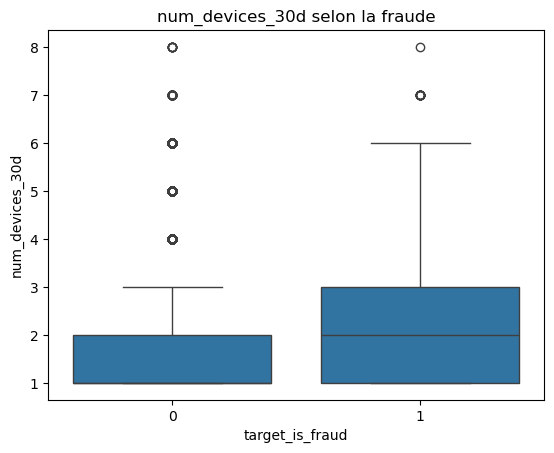

In [ ]:
sns.boxplot(x=df['target_is_fraud'], y=df['num_devices_30d'])
plt.title('num_devices_30d selon la fraude')
plt.show()

In [57]:
df.groupby('target_is_fraud')['is_new_device'].value_counts(normalize=True)

target_is_fraud  is_new_device
0                0                0.820817
                 1                0.179183
1                0                0.756296
                 1                0.243704
Name: proportion, dtype: float64

In [58]:
df.groupby('target_is_fraud')['device_type'].value_counts(normalize=True)

target_is_fraud  device_type
0                phone          0.518804
                 desktop        0.210452
                 laptop         0.179989
                 tablet         0.080541
                 iot_device     0.010214
1                phone          0.524777
                 desktop        0.211210
                 laptop         0.176483
                 tablet         0.078798
                 iot_device     0.008733
Name: proportion, dtype: float64